In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resolve repo root whether launched from repo root or Notebooks/
repo_root = Path.cwd().resolve()
if not (repo_root / "backtesting" / "test_001_nvda").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

import common

# ── Strategy configuration ───────────────────────────────────────────────
STRATEGY_DIR = repo_root / "backtesting" / "test_001_nvda"
config = common.load_strategy_config(STRATEGY_DIR / "strategy_config.json")

SYMBOL = config["stock_symbol"]
MODEL_NAME = config["model_name"]
START = config["backtest_start"]
END = config["backtest_end"]
PROVIDER = config["data_src"]

# Full indicator spec — all available indicators computed upfront.
# Models pick the columns they need from this enriched DataFrame.
INDICATOR_SPEC = {
    "rsi":         {"period": 14},
    "macd":        {"fast": 12, "slow": 26, "signal": 9},
    "cci":         {"period": 20},
    "bbp":         {"period": 20},
    "stochastic":  {"window": 14, "smooth": 3},
    "adx":         {"period": 14},
    "atr":         {"period": 14},
    "obv":         {"signal_period": 20},
    "williams_r":  {"period": 14},
    "ema":         {"period": 50},
    "momentum":    {"period": 10},
}

# Shared feature columns — same 7 indicators used by ALL models for fair comparison.
# Manual model votes on these via threshold rules; ML models use them as inputs.
FEATURE_COLUMNS = ["rsi", "macd_hist", "cci", "bbp", "adx", "williams_r", "obv_slope"]

print(f"Strategy: {MODEL_NAME}")
print(f"Symbol:   {SYMBOL}")
print(f"Window:   {START} -> {END}")
print(f"Indicators: {list(INDICATOR_SPEC.keys())}")
print(f"Shared features: {FEATURE_COLUMNS}")

In [ ]:
# ── Fetch OHLCV data and compute indicators ─────────────────────────────
df = common.fetch_ohlcv(SYMBOL, start=START, end=END, provider=PROVIDER)
df = common.compute_indicators(df, INDICATOR_SPEC).dropna()

print(f"Bars: {len(df)}  ({df.index[0].date()} -> {df.index[-1].date()})")
print(f"Features: {FEATURE_COLUMNS}")
df[["close", *FEATURE_COLUMNS]].tail()

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# MODEL 1: Manual — multi-indicator threshold voting (no ML)
# ══════════════════════════════════════════════════════════════════════════
# 7 indicators vote. Each can contribute +1 (bullish) or -1 (bearish).
# Buy when >= 3 agree bullish; sell when <= -3 agree bearish.
#
# Thresholds tuned for NVDA's high-momentum profile:
#   - RSI 40/65 (wider buy band than textbook 30/70, because NVDA rarely dips below 30)
#   - Williams %R -80/-20 (standard oversold/overbought)
#   - BBP -0.8/0.8 (near Bollinger Bands)
#   - ADX > 25 confirms trend strength (bullish when trending)
#   - OBV slope > 0 means accumulation (volume confirming price)
#   - MACD hist > 0 / < 0 (momentum direction)
#   - CCI < -100 / > 100 (extreme oversold / overbought)
MANUAL_SCORE_RULES = [
    {"col": "rsi",        "buy_below": 40,    "sell_above": 65},
    {"col": "williams_r", "buy_below": -80,   "sell_above": -20},
    {"col": "bbp",        "buy_below": -0.8,  "sell_above": 0.8},
    {"col": "adx",        "buy_above": 25},
    {"col": "obv_slope",  "buy_above": 0,     "sell_below": 0},
    {"col": "macd_hist",  "buy_above": 0,     "sell_below": 0},
    {"col": "cci",        "buy_below": -100,  "sell_above": 100},
]

manual_model = common.create_model(
    "manual",
    score_rules=MANUAL_SCORE_RULES,
    buy_threshold=3,
    sell_threshold=-3,
)
manual_meta = manual_model.train(df)

manual_signals = manual_model.predict_bulk(df)
print("Manual model signal distribution:")
print(manual_signals.value_counts())
print(f"\n{len(MANUAL_SCORE_RULES)} rules, buy >= 3, sell <= -3")

In [19]:
# ══════════════════════════════════════════════════════════════════════════
# MODEL 2: Classification — BagLearner(RTLearner) bagged decision trees
# ══════════════════════════════════════════════════════════════════════════
# Labels each day by its N-day forward return, then trains a bagged random
# forest to classify buy (+1) / sell (-1) / hold (0).
#
# Strategy-specific params for NVDA:
#   - 10-day lookahead, 4% threshold for label generation
#   - buy_threshold=0.1 / sell_threshold=-0.1 because the ensemble average
#     of {-1, 0, +1} predictions is typically close to 0 in trending markets.
#     The default ±0.5 is too strict and suppresses sell signals entirely.
CLASSIFICATION_PARAMS = {
    "feature_columns": FEATURE_COLUMNS,
    "lookahead": 10,
    "threshold": 0.04,
    "leaf_size": 25,
    "bags": 15,
    "buy_threshold": 0.1,
    "sell_threshold": -0.1,
}

clf_model = common.create_model("classification", **CLASSIFICATION_PARAMS)
clf_meta = clf_model.train(df)

clf_signals = clf_model.predict_bulk(df)
print("Classification model training metadata:")
print(clf_meta)
print(f"\nSignal distribution:")
print(clf_signals.value_counts())

Classification model training metadata:
{'model_type': 'classification', 'train_rows': 764, 'label_distribution': {'long': 331, 'hold': 291, 'short': 142}}

Signal distribution:
buy     664
hold     76
sell     25
Name: count, dtype: int64


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# MODEL 3: Q-Learning — tabular RL with discretized indicator states
# ══════════════════════════════════════════════════════════════════════════
# Discretizes continuous indicators into bins, encodes (bins + holding) as
# a single state integer, and learns a Q-table via epsilon-greedy exploration.
#
# With 7 features, bins must be small to keep the state space manageable:
# 4^7 * 3 = 49,152 states (vs 10^3 * 3 = 3,000 with 3 features @ 10 bins).
QLEARNING_PARAMS = {
    "feature_columns": FEATURE_COLUMNS,
    "n_bins": 4,
    "n_epochs": 200,
    "alpha": 0.2,
    "gamma": 0.9,
    "rar": 0.98,
    "radr": 0.999,
    "dyna": 0,
}

ql_model = common.create_model("qlearning", **QLEARNING_PARAMS)
ql_meta = ql_model.train(df)

ql_signals = ql_model.predict_bulk(df)
print("Q-Learning model training metadata:")
print(ql_meta)
print(f"\nSignal distribution:")
print(ql_signals.value_counts())

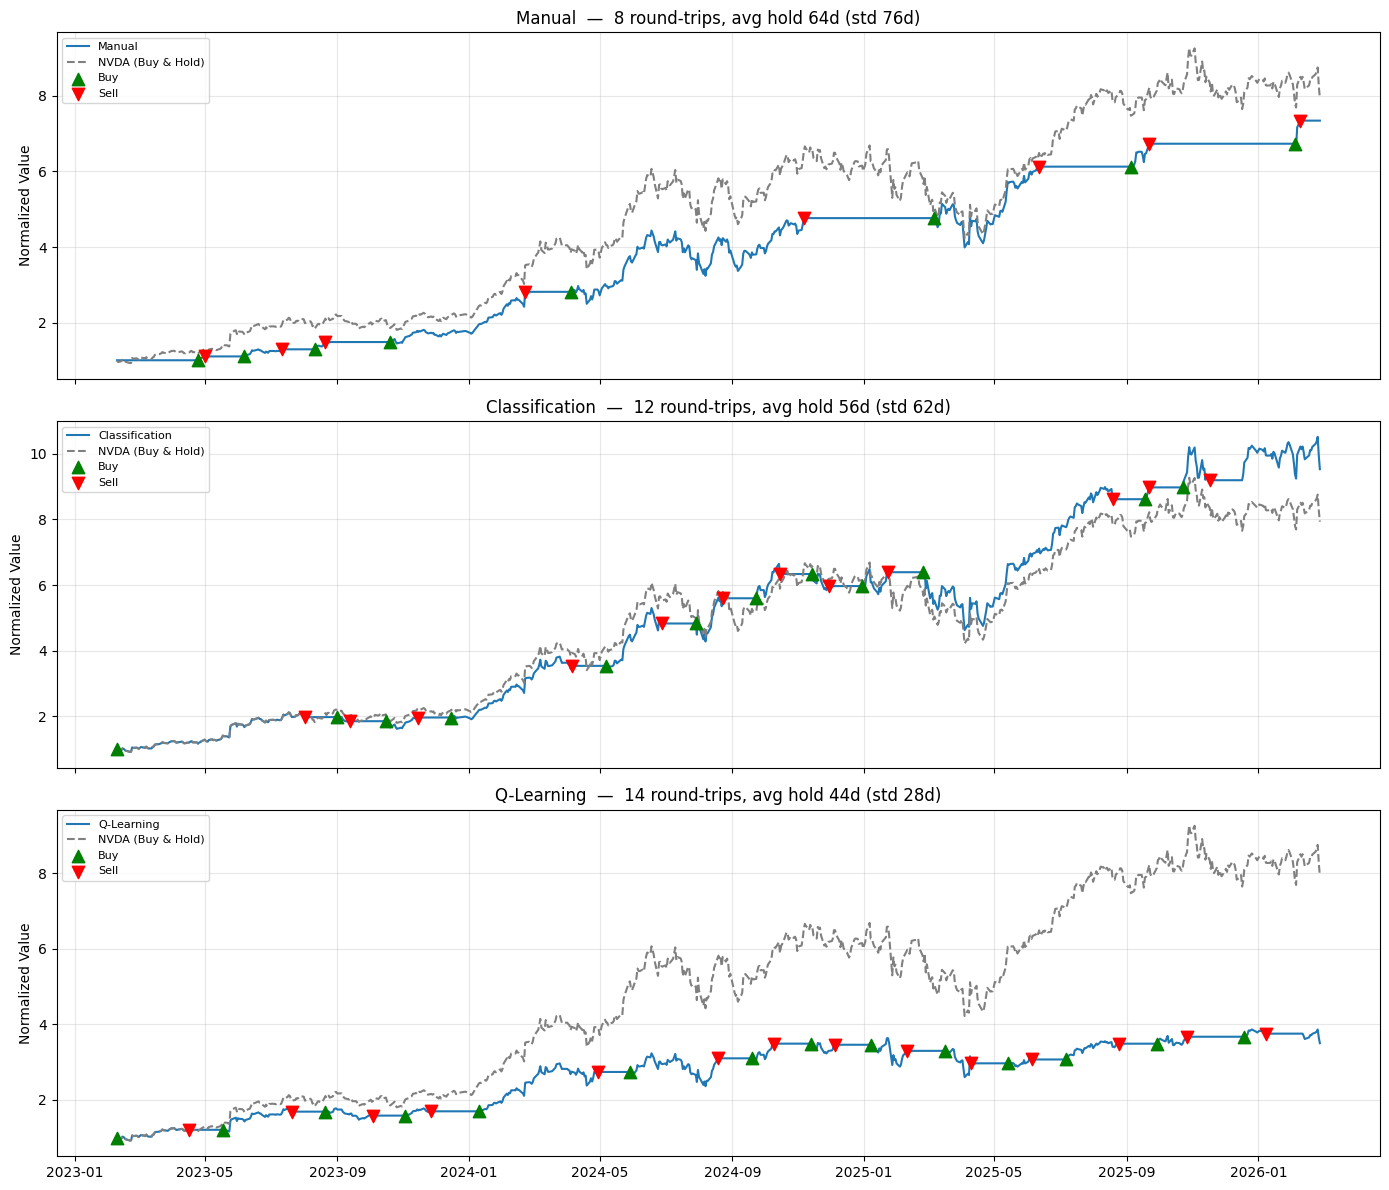

,Model,Return,Sharpe,Round-trips,Avg Hold,Std Hold
0,Manual,634.74%,2.01,8,64d,76d
1,Classification,852.94%,1.99,12,56d,62d
2,Q-Learning,250.26%,1.23,14,44d,28d
3,NVDA Buy & Hold,693.26%,1.63,1,1114d,—


In [21]:
# ══════════════════════════════════════════════════════════════════════════
# Compare all three models
# ══════════════════════════════════════════════════════════════════════════

# ── Strategy-specific simulation parameters ──────────────────────────────
INITIAL_CASH = 10_000          # starting capital
WASH_SALE_DAYS = 30            # cannot buy within N days after a sell
QL_MIN_HOLD_DAYS = 20          # Q-Learning: minimum holding period per trade


def apply_constraints(signals, min_hold_days=0, wash_sale_days=0):
    """Filter raw signals to enforce holding period and wash-sale rules."""
    out = signals.values.copy()
    dates = signals.index
    position = 0
    entry_idx = None
    last_sell_idx = None

    for i in range(len(out)):
        sig = out[i]
        if sig == "buy" and position == 0:
            if last_sell_idx is not None and (dates[i] - dates[last_sell_idx]).days < wash_sale_days:
                out[i] = "hold"
                continue
            position = 1
            entry_idx = i
        elif sig == "sell" and position == 1:
            if entry_idx is not None and (dates[i] - dates[entry_idx]).days < min_hold_days:
                out[i] = "hold"
                continue
            position = 0
            last_sell_idx = i
            entry_idx = None
        else:
            if (sig == "sell" and position == 0) or (sig == "buy" and position == 1):
                out[i] = "hold"
    return pd.Series(out, index=signals.index)


def simulate_equity(signals, prices, initial_cash=INITIAL_CASH):
    """Simulate a long-only equity curve. Returns (equity, trades)."""
    close = prices.values
    sigs = signals.values
    cash = float(initial_cash)
    shares = 0
    equity = np.empty(len(sigs))
    trades = []
    entry_idx = None

    for i in range(len(sigs)):
        p = close[i]
        if sigs[i] == "buy" and shares == 0:
            shares = int(cash // p)
            cash -= shares * p
            entry_idx = i
        elif sigs[i] == "sell" and shares > 0:
            cash += shares * p
            shares = 0
            if entry_idx is not None:
                trades.append((signals.index[entry_idx], signals.index[i]))
                entry_idx = None
        equity[i] = cash + shares * p
    return pd.Series(equity, index=signals.index), trades


# Apply constraints per model
constrained = {
    "Manual": apply_constraints(manual_signals, wash_sale_days=WASH_SALE_DAYS),
    "Classification": apply_constraints(clf_signals, wash_sale_days=WASH_SALE_DAYS),
    "Q-Learning": apply_constraints(ql_signals, min_hold_days=QL_MIN_HOLD_DAYS,
                                    wash_sale_days=WASH_SALE_DAYS),
}

# ── Charts ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(len(constrained), 1, figsize=(14, 4 * len(constrained)), sharex=True)

for ax, (name, signals) in zip(axes, constrained.items()):
    eq, trades = simulate_equity(signals, df["close"])
    norm_eq = eq / eq.iloc[0]
    benchmark = df["close"] / df["close"].iloc[0]

    ax.plot(norm_eq.index, norm_eq, label=name, linewidth=1.5)
    ax.plot(benchmark.index, benchmark, label=f"{SYMBOL} (Buy & Hold)",
            linestyle="--", color="gray", linewidth=1.5)

    buy_dates = [t[0] for t in trades]
    sell_dates = [t[1] for t in trades]
    if buy_dates:
        ax.scatter(buy_dates, norm_eq.loc[buy_dates], marker="^", color="green",
                   s=80, zorder=5, label="Buy")
    if sell_dates:
        ax.scatter(sell_dates, norm_eq.loc[sell_dates], marker="v", color="red",
                   s=80, zorder=5, label="Sell")

    if trades:
        hold_days = [(s - b).days for b, s in trades]
        avg_hold = np.mean(hold_days)
        std_hold = np.std(hold_days, ddof=1) if len(hold_days) > 1 else 0
        ax.set_title(f"{name}  —  {len(trades)} round-trips, "
                     f"avg hold {avg_hold:.0f}d (std {std_hold:.0f}d)")
    else:
        ax.set_title(f"{name}  —  0 round-trips")

    ax.set_ylabel("Normalized Value")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Summary table ────────────────────────────────────────────────────────
summary = []
for name, signals in constrained.items():
    eq, trades = simulate_equity(signals, df["close"])
    total_ret = eq.iloc[-1] / eq.iloc[0] - 1
    daily_rets = eq.pct_change().dropna()
    sharpe = daily_rets.mean() / daily_rets.std() * np.sqrt(252) if daily_rets.std() > 0 else 0
    n_trades = len(trades)
    hold_days = [(s - b).days for b, s in trades]
    avg_hold = f"{np.mean(hold_days):.0f}d" if hold_days else "—"
    std_hold = f"{np.std(hold_days, ddof=1):.0f}d" if len(hold_days) > 1 else "—"
    summary.append({
        "Model": name, "Return": f"{total_ret:.2%}", "Sharpe": f"{sharpe:.2f}",
        "Round-trips": n_trades, "Avg Hold": avg_hold, "Std Hold": std_hold,
    })

bh_ret = df["close"].iloc[-1] / df["close"].iloc[0] - 1
bh_daily = df["close"].pct_change().dropna()
bh_sharpe = bh_daily.mean() / bh_daily.std() * np.sqrt(252)
bh_days = (df.index[-1] - df.index[0]).days
summary.append({
    "Model": f"{SYMBOL} Buy & Hold", "Return": f"{bh_ret:.2%}", "Sharpe": f"{bh_sharpe:.2f}",
    "Round-trips": 1, "Avg Hold": f"{bh_days}d", "Std Hold": "—",
})

pd.DataFrame(summary)

In [22]:
# ══════════════════════════════════════════════════════════════════════════
# Export best model
# ══════════════════════════════════════════════════════════════════════════
# Automatically selects the model with the highest Sharpe ratio after
# constraints, cleans up old artifacts, and exports the winner.

import glob

# Pick best model by Sharpe
best_name, best_sharpe, best_model = None, -np.inf, None
model_map = {"Manual": manual_model, "Classification": clf_model, "Q-Learning": ql_model}

for name, signals in constrained.items():
    eq, _ = simulate_equity(signals, df["close"])
    daily_rets = eq.pct_change().dropna()
    sharpe = daily_rets.mean() / daily_rets.std() * np.sqrt(252) if daily_rets.std() > 0 else 0
    if sharpe > best_sharpe:
        best_name, best_sharpe, best_model = name, sharpe, model_map[name]

# Clean up old model artifacts before exporting
old_artifacts = glob.glob(str(STRATEGY_DIR / f"{MODEL_NAME}-*.json"))
for path in old_artifacts:
    Path(path).unlink()
    print(f"  removed {Path(path).name}")

# Export the winner
metadata = best_model.save(STRATEGY_DIR, MODEL_NAME)

print(f"\nBest model: {best_name} (Sharpe {best_sharpe:.2f})")
print(f"Exported to {STRATEGY_DIR}/")
print(f"Artifacts: {list(metadata.get('artifacts', {}).keys())}")


Best model: Manual (Sharpe 2.01)
Exported to /Users/renhao/git/github/RenQuant/backtesting/test_001_nvda/
Artifacts: ['rules']
